In [3]:
import numpy as np
import matplotlib.pyplot as plt
def gen_I_Q_qpsk(N_symbols):
    levels = np.array([-1, 1]) / np.sqrt(2)

    qam_symbols_x = (np.random.choice(levels, N_symbols) +
                     1j * np.random.choice(levels, N_symbols))
    qam_symbols_y = (np.random.choice(levels, N_symbols) +
                     1j * np.random.choice(levels, N_symbols))

    E_in = np.column_stack((qam_symbols_x, qam_symbols_y))
    return E_in

def first_eleven():
    X = np.array([
        -3+3j,  3+3j, -3+3j,  3+3j, -3-3j, 3+3j, -3-3j, -3-3j,  3+3j,  3-3j,  3-3j
        ])
    Y = np.array([
        -3-3j, -3-3j,  3-3j, -3+3j, -3+3j, 3+3j, -3-3j, -3+3j,  3-3j,  3+3j,  3-3j
        ])
    norm = np.sqrt(18)
    return X / norm, Y / norm

def lfsr_sequence(seed, length):
    # 10-bit shift register based on x^10 + x^8 + x^4 + x^3 + 1
    
    state = seed & 0x3FF  # keep 10 bits
    seq = []

    for _ in range(length):
        b9 = (state >> 9) & 1 #x^10
        b7 = (state >> 7) & 1 #x^8
        b3 = (state >> 3) & 1 #x^4
        b2 = (state >> 2) & 1 #x^3
        b0 = (state >> 0) & 1 #1

        new_bit = b9 ^ b7 ^ b3 ^ b2 ^ b0

        # output is last bit
        seq.append(b0)

        # state update with feedback loop
        state = ((state << 1) & 0x3FF) | new_bit

    return np.array(seq)


def generate_lfsr_pilots(seed, num_pilots):
    bits = lfsr_sequence(seed, num_pilots * 2)
    symbols = []
    # generating symbols from the bits
    # using pairwise bits to get the real and imag part of symbol
    for i in range(num_pilots):
        b1 = bits[2*i]
        b2 = bits[2*i + 1]
        # generate real part as 3 if odd bit is 1, else -3
        # generate imag part as 3 if even bit is 1, else -3
        real = 1 if b1 else -1
        imag = 1 if b2 else -1

        symbols.append(real + 1j * imag)

    return np.array(symbols) / np.sqrt(2)


def generate_frame():
    frame_len = 64

    frame_x = np.zeros(frame_len, dtype=complex)
    frame_y = np.zeros(frame_len, dtype=complex)

    # first 32 bit section:

    x_pilots_11, y_pilots_11 = first_eleven()

    idx = 0
    frame_x[idx:idx+11] = x_pilots_11
    frame_y[idx:idx+11] = y_pilots_11
    idx += 11
    
    data = gen_I_Q_qpsk(21)
    frame_x[idx : idx+21] = data[ : , 0]
    frame_y[idx : idx+21] = data[ : , 1]
    idx += 21

    # remaining sections:

    # seed X = 0x19E, seed Y = 0x0D0 for the remaining 115 pilots
    lfsr_x = generate_lfsr_pilots(0x19E, 1)
    lfsr_y = generate_lfsr_pilots(0x0D0, 1)

    print(lfsr_x[:10])

    for i in range(1):
        # pilot
        frame_x[idx] = lfsr_x[i]
        frame_y[idx] = lfsr_y[i]
        idx += 1

        # data
        data = gen_I_Q_qpsk(31)
        frame_x[idx:idx+31] = data[:, 0]
        frame_y[idx:idx+31] = data[:, 1]
        idx += 31

    return np.column_stack((frame_x, frame_y))

# def generate_mask():

def plot_loss_vs_tau(pilot_stream):
    shift_arr = []
    loss_arr = []
    for shift in range(-20,20):
        shifted_pilots = np.roll(pilot_stream, shift, axis=0)
        shifted_pilots_fft = np.fft.fft(shifted_pilots, axis=0)
        pilot_stream_fft = np.fft.fft(pilot_stream, axis=0)
        loss = np.mean(np.abs(pilot_stream_fft - shifted_pilots_fft)**2)
        shift_arr.append(shift)
        loss_arr.append(loss)
    plt.plot(shift_arr, loss_arr)
    plt.xlabel("Tau")
    plt.ylabel("Loss")
    plt.title("Loss vs Tau for 20 offset and 64 frame size (Peaks at 44, 44+64, ...)")
    plt.show()

def plot_loss_vs_tau_time(signal, pilots):
    losses = []
    shifts = range(0, len(signal) - len(pilots))

    for shift in shifts:
        segment = signal[shift:shift+len(pilots)]

        loss = np.mean(np.abs(segment - pilots)**2)
        losses.append(loss)

    plt.plot(shifts, losses)
    plt.xlabel("Tau")
    plt.ylabel("Loss")
    plt.title("Loss vs Tau for 20 offset and 64 frame size (Peaks at 44, 44+64, ...)")
    plt.grid()
    plt.show()

def generate_stream(N_total,offset):
    frame_len = 64
    num_frames = int(np.ceil(N_total / frame_len)) + 1

    #print("num_frames:", num_frames)
    stream = np.vstack([generate_frame() for _ in range(num_frames)])

    #print("stream shape:", stream.shape)
    stream = stream[offset:]
    #print("stream shape after offset:", stream.shape)
    #print("offset is",offset)
    return stream[:N_total]


[-0.70710678+0.70710678j]
[-0.70710678+0.70710678j]
[-0.70710678+0.70710678j]
[-0.70710678+0.70710678j]
[-0.70710678+0.70710678j]
shape:
(11, 2)
(256, 2)
hello


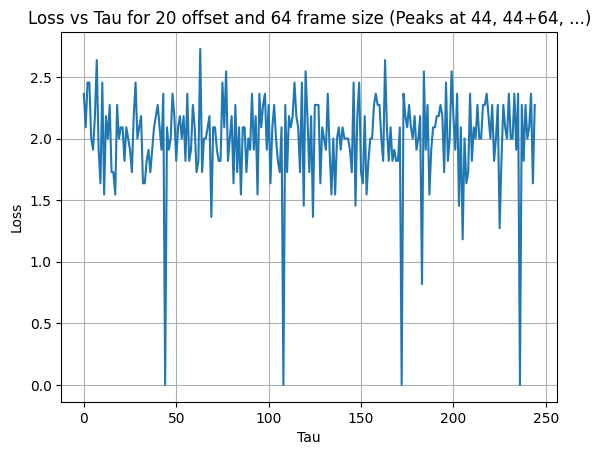

In [4]:
N_symbols = 256
E_in = generate_stream(N_symbols,offset=20)
x_p, y_p = first_eleven()
pilots = np.column_stack((x_p, y_p))
print("shape:")
print(pilots.shape)
print(E_in.shape)
print("hello")
plot_loss_vs_tau_time(E_in, pilots)
